In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\data\processed\featured_data.csv")

In [4]:
print(df.shape)
df.head()

(8917, 181)


,total_sqft,bath,price,bhk,price_per_sqft,location_ Devarachikkanahalli,location_1st Phase JP Nagar,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,...,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1672.0,3.0,150.0,3,8971.29,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1750.0,3.0,149.0,3,8514.29,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1750.0,3.0,150.0,3,8571.43,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1250.0,2.0,44.0,3,3520.00,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1250.0,2.0,40.0,2,3200.00,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
x = df.drop(columns = ["price"]) #all columns except price are features
y = df["price"]
print(x.shape)
print(y.shape)
print(y.head().values)

(8917, 180)
(8917,)
[150. 149. 150.  44.  40.]


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42) #80% training set, 20% test set
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7133, 180)
(1784, 180)
(7133,)
(1784,)


In [7]:
# Linear Regression model
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
print("Training Score:", lr_model.score(x_train, y_train)) # R squared
print("Test Score:", lr_model.score(x_test, y_test))

Training Score: 0.865444864908289
Test Score: 0.9215771235958772


In [8]:
#cross validation
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores = cross_val_score(lr_model, x, y, cv=cv)

print("Cross Validation Scores:", np.round(scores, 4))
print("Mean Score:", round(scores.mean(), 4))
print("Std Deviation:", round(scores.std(), 4))

Cross Validation Scores: [0.9216 0.8363 0.923  0.8929 0.939 ]
Mean Score: 0.9026
Std Deviation: 0.0363


- CV - 5 splits, each time training on 80% and testing on 205
- CV test scores: [0.9216 0.8363 0.923  0.8929 0.939 ]
- on average LR model explains 90% of price variation

In [9]:
#Decision Tree model
dt_model = DecisionTreeRegressor(random_state = 42)
dt_model.fit(x_train,y_train)
print("Training Score:", (dt_model.score(x_train,y_train)))
print("Test Score:", (dt_model.score(x_test,y_test)))
dt_scores = cross_val_score(dt_model,x,y, cv = cv)
print("CV Mean Score:", dt_scores.mean())
print("CV standard deviation:", dt_scores.std())

Training Score: 1.0
Test Score: 0.741837371548163
CV Mean Score: 0.9028496031732895
CV standard deviation: 0.10523479245219379


In [10]:
#Lasso model
ls_model = Lasso(alpha = 1.0)
ls_model.fit(x_train,y_train)
print("Training Score:", (ls_model.score(x_train,y_train)))
print("Test Score:", (ls_model.score(x_test,y_test)))
ls_scores = cross_val_score(ls_model,x,y, cv = cv)
print("CV Mean Score:", ls_scores.mean())
print("CV standard deviation:", ls_scores.std())

Training Score: 0.8450206828920979
Test Score: 0.9081001898733071
CV Mean Score: 0.8904508153822727
CV standard deviation: 0.04186634834741953


In [11]:
import pickle
import json

# Save the model
with open(r"C:\Users\HP\Desktop\RealEstatePricePrediction\models\best_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save the column names
columns = x.columns.tolist()
with open(r"C:\Users\HP\Desktop\RealEstatePricePrediction\models\columns.json", "w") as f:
    json.dump({"data_columns": columns}, f)

print("Model saved successfully!")
print("Columns saved successfully!")

Model saved successfully!
Columns saved successfully!


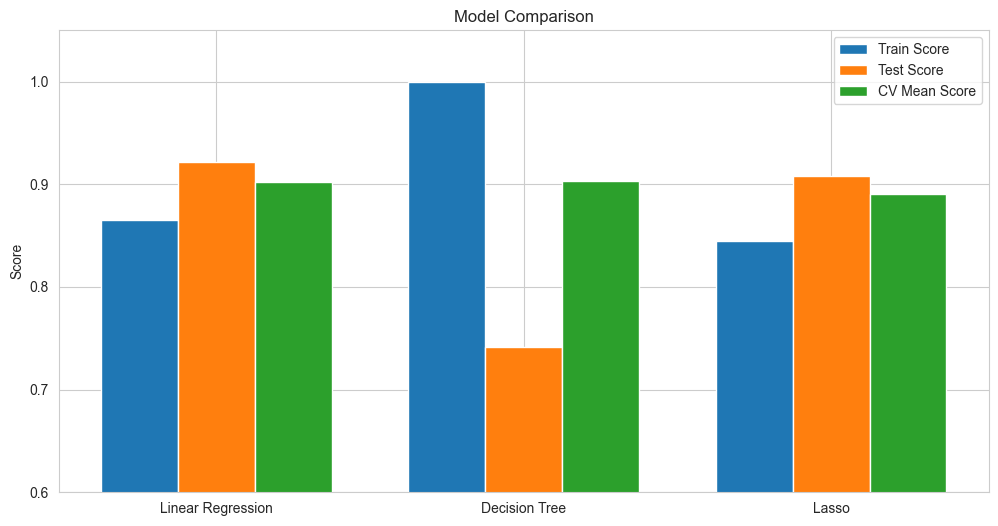

In [12]:
#model comparison chart
models = ["Linear Regression", "Decision Tree", "Lasso"]
train_scores = [0.8654, 1.0, 0.8450]
test_scores = [0.9216, 0.7418, 0.9081]
cv_scores = [0.9026, 0.9028, 0.8904]
x_axis = np.arange(len(models))
width = 0.25

plt.figure(figsize = (12,6))
plt.bar(x_axis - width, train_scores, width, label = "Train Score")
plt.bar(x_axis, test_scores, width, label = "Test Score")
plt.bar(x_axis + width, cv_scores, width, label = "CV Mean Score")
plt.xticks(x_axis, models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.ylim(0.6,1.05)
plt.show()

## Model Comparison Summary

| Model | Train | Test | CV Mean | CV Std | Verdict |
|---|---|---|---|---|---|
| Linear Regression | 0.865 | 0.921 | 0.902 | 0.036 | Best model |
| Decision Tree | 1.000 | 0.742 | 0.903 | 0.105 | Overfitting |
| Lasso (alpha=1) | 0.845 | 0.908 | 0.890 | 0.041 | Good but weak |

- Linear Regression chosen as best model
- Saved to models/best_model.pkl
- Column names saved to models/columns.json

In [13]:
import csv

results = {
    "Model": ["Linear Regression", "Decision Tree", "Lasso"],
    "Train Score": [0.8654, 1.0, 0.8450],
    "Test Score": [0.9216, 0.7418, 0.9081],
    "CV Mean Score": [0.9026, 0.9028, 0.8904],
    "CV Std": [0.0363, 0.1052, 0.0419]
}

pd.DataFrame(results).to_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\reports\model_comparison.csv", index=False)
print("Model comparison saved!")

Model comparison saved!
